In [1]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.utils import to_categorical

# Reproducibility (score-stable; does not change core logic)
np.random.seed(42)
try:
    keras.utils.set_random_seed(42)
except Exception:
    pass

# Paths (match Kaggle dataset layout described by user)
BASE_PATH = "/kaggle/input/leaf-classification"
TRAIN_PATH = os.path.join(BASE_PATH, "train.csv")
TEST_PATH = os.path.join(BASE_PATH, "test.csv")
SAMPLE_SUB_PATH = os.path.join(BASE_PATH, "sample_submission.csv")

assert os.path.exists(TRAIN_PATH), f"Missing: {TRAIN_PATH}"
assert os.path.exists(TEST_PATH), f"Missing: {TEST_PATH}"
assert os.path.exists(SAMPLE_SUB_PATH), f"Missing: {SAMPLE_SUB_PATH}"



2026-01-16 10:25:46.088722: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768559146.102914      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768559146.107228      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-16 10:25:46.126941: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
# Load data
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

parent_data = train_df.copy()

train_ids = train_df.pop("id").values
y_raw = train_df.pop("species").values
X_df = train_df  # remaining 192 features

test_ids = test_df.pop("id").values
X_test_df = test_df

print("Train features:", X_df.shape, "Train labels:", y_raw.shape)
print("Test features:", X_test_df.shape)
print("Sample submission:", sample_sub.shape)



Train features: (891, 192) Train labels: (891,)
Test features: (99, 192)
Sample submission: (99, 100)


In [3]:
# Encode labels
le = LabelEncoder()
y = le.fit_transform(y_raw)

# One-hot labels
y_cat = to_categorical(y, num_classes=len(le.classes_))

print("Num classes:", len(le.classes_))
print("y_cat:", y_cat.shape)



Num classes: 99
y_cat: (891, 99)


In [4]:
# Scale features: fit on train, transform train/test with SAME scaler (bug fix; score-positive/stable)
scaler = StandardScaler()
X = scaler.fit_transform(X_df.values)
X_test = scaler.transform(X_test_df.values)

print("Scaled X:", X.shape, "Scaled X_test:", X_test.shape)



Scaled X: (891, 192) Scaled X_test: (99, 192)


In [5]:
# Model definition (preserve core architecture; only update deprecated args)
model = Sequential()
model.add(
    Dense(2048, input_dim=X.shape[1], kernel_initializer="uniform", activation="relu")
)
model.add(Dropout(0.3))
model.add(Dense(1024, activation="relu"))
model.add(Dropout(0.3))
model.add(Dense(y_cat.shape[1], activation="softmax"))

model.compile(
    loss="categorical_crossentropy", optimizer="rmsprop", metrics=["accuracy"]
)
model.summary()



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-16 10:25:51.936260: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1768559151.936669      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 40005 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:46:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2048)           │       395,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 99)             │       101,475 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,594,915 (9.90 MB)

 Trainable params: 2,594,915 (9.90 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Training (preserve loop; update nb_epoch -> epochs)
history = model.fit(
    X,
    y_cat,
    batch_size=192,
    epochs=20,
    verbose=0,
    validation_split=0.1,
)



I0000 00:00:1768559152.957026      68 service.cc:148] XLA service 0x7fe378005bf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768559152.957070      68 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-01-16 10:25:52.975359: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1768559153.033059      68 cuda_dnn.cc:529] Loaded cuDNN version 90300
2026-01-16 10:25:53.654773: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_905', 1196 bytes spill stores, 1200 bytes spill loads

2026-01-16 10:25:53.845081: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_905', 452 bytes spi

In [7]:
# History keys differ across keras versions; handle robustly
print("History keys:", list(history.history.keys()))

acc_key = (
    "accuracy"
    if "accuracy" in history.history
    else ("acc" if "acc" in history.history else None)
)
val_acc_key = (
    "val_accuracy"
    if "val_accuracy" in history.history
    else ("val_acc" if "val_acc" in history.history else None)
)

if acc_key is not None:
    print("acc:", float(np.max(history.history[acc_key])))
print("loss:", float(np.min(history.history["loss"])))

if val_acc_key is not None:
    print("val_acc:", float(np.max(history.history[val_acc_key])))
print("val_loss:", float(np.min(history.history["val_loss"])))



History keys: ['accuracy', 'loss', 'val_accuracy', 'val_loss']
acc: 1.0
loss: 0.004548839759081602
val_acc: 1.0
val_loss: 0.023554757237434387


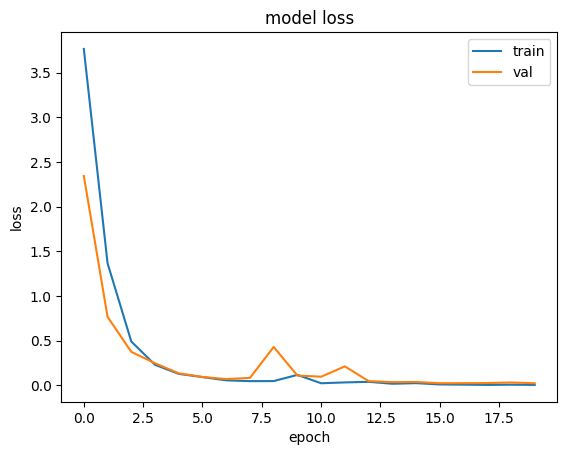

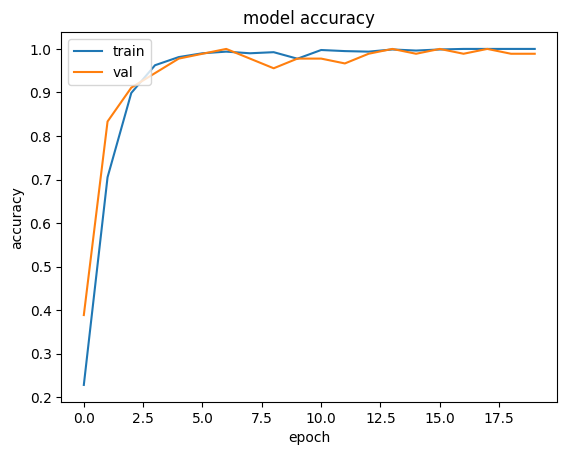

In [8]:
# Optional plots (won't break if run headless)
plt.figure()
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(loc="upper right")
plt.show()

if acc_key is not None and val_acc_key is not None:
    plt.figure()
    plt.plot(history.history[acc_key], label="train")
    plt.plot(history.history[val_acc_key], label="val")
    plt.title("model accuracy")
    plt.ylabel("accuracy")
    plt.xlabel("epoch")
    plt.legend(loc="upper left")
    plt.show()



In [9]:
# Predict probabilities (Keras 3 uses predict; predict_proba removed)
y_pred = model.predict(X_test, verbose=0)

# Safety: clip into [0, 1] (metric will clip anyway, but ensures validity)
y_pred = np.clip(y_pred, 0.0, 1.0)

print("Pred shape:", y_pred.shape)



2026-01-16 10:26:05.735626: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_16_0', 76 bytes spill stores, 248 bytes spill loads

2026-01-16 10:26:05.770361: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_23', 336 bytes spill stores, 336 bytes spill loads

2026-01-16 10:26:06.415516: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_16', 196 bytes spill stores, 196 bytes spill loads

2026-01-16 10:26:07.440897: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_23', 208 bytes spill stores, 208 bytes spill loads

2026-01-16 10:26:07.451083: I external/local_xla/xla/stream

Pred shape: (99, 99)


In [10]:
# Build submission with correct column order from sample_submission.csv (prevents class/order mismatch)
sub_cols = list(sample_sub.columns)
assert sub_cols[0] == "id", "Sample submission must start with 'id'."
class_cols = sub_cols[1:]

# Map model class order -> submission column order
# le.classes_ are the original species names in the order used for training/softmax.
model_class_names = list(le.classes_)
model_name_to_idx = {name: i for i, name in enumerate(model_class_names)}

# Ensure all expected classes exist
missing = [c for c in class_cols if c not in model_name_to_idx]
extra = [c for c in model_class_names if c not in set(class_cols)]
assert (
    len(missing) == 0
), f"Classes in sample_submission missing from model labels: {missing[:5]}"
assert (
    len(extra) == 0
), f"Classes in model labels missing from sample_submission: {extra[:5]}"

# Reorder predictions to match submission columns
ordered_pred = np.zeros((y_pred.shape[0], len(class_cols)), dtype=np.float64)
for j, cname in enumerate(class_cols):
    ordered_pred[:, j] = y_pred[:, model_name_to_idx[cname]]

submission = pd.DataFrame(ordered_pred, columns=class_cols)
submission.insert(0, "id", test_ids)

print(submission.head())
print("Submission shape:", submission.shape)



     id  Acer_Capillipes  Acer_Circinatum     Acer_Mono   Acer_Opalus  \
0  1202     8.682403e-06     1.117671e-05  2.736673e-04  1.062598e-04   
1   992     1.983324e-06     2.570316e-08  2.106672e-08  1.078403e-06   
2   491     3.687327e-05     9.910052e-06  1.932129e-05  8.985486e-05   
3  1201     3.705109e-07     3.226509e-08  2.045896e-05  1.554421e-05   
4    72     2.351548e-08     8.831923e-09  2.148757e-06  1.609435e-08   

   Acer_Palmatum   Acer_Pictum  Acer_Platanoids   Acer_Rubrum  Acer_Rufinerve  \
0   1.120909e-05  7.356839e-05     6.100822e-06  6.892714e-05    1.849435e-06   
1   4.683971e-06  1.524115e-07     5.656647e-09  2.912027e-08    3.359830e-07   
2   6.671581e-06  1.415412e-04     1.999042e-06  1.862421e-05    1.939179e-05   
3   5.921195e-08  8.567570e-08     5.112001e-07  1.927713e-08    1.322130e-08   
4   4.647718e-09  1.879517e-06     3.594653e-08  1.269247e-09    1.035042e-09   

   ...  Salix_Fragilis  Salix_Intergra   Sorbus_Aria  Tilia_Oliveri  \
0  

In [11]:
# Write submission
out_path = "submission_nn_kernel.csv"
submission.to_csv(out_path, index=False)
print("Wrote:", out_path)
print(
    "Columns OK:",
    submission.columns[0] == "id" and submission.shape[1] == sample_sub.shape[1],
)

Wrote: submission_nn_kernel.csv
Columns OK: True
